# Calculate and visualize reference activation levels for WM, Emotion, and Language tasks

For information on how to use this notebook along with the original `.ipynb` file, please check the corresponding [Python notebook in the preprocessing reports repository from Dr. Raúl Rodriguez Cruces](https://github.com/rcruces/preproc_reports/blob/main/notebooks/2024_neurosynth-ICBM152-fsLR.ipynb).

Please note that a significant part of this notebook is different from the original version by Dr. Raúl Rodriguez Cruces. Most of the code is set in a way that eliminates using containers and heavy software.

## Setup
The MNI atlases are stored in `./ref_activation_ns/data/` and Neurosynth `association-test_z_FDR_0.01.nii.gz` files for Working Memory, Fear, Neutral, and Language tasks are stored in a folder with this path: `./ref_activation_ns/data/NS_ref_activation_data`

In [1]:
!pip install nilearn --quiet
!pip install nibabel --quiet
!pip install seaborn --quiet
!pip install brainspace --quiet

import os
import tempfile
import requests
import numpy as np
import nibabel as nib
import seaborn as sns
import matplotlib.pyplot as plt

from nilearn import plotting, datasets
from brainspace.utils.parcellation import map_to_labels

Next, navigate to the main directory and run this code in your terminal:
```bash
fslmaths ./ref_activation_ns/data/mni_icbm152_nlin_asym_09a_nifti/mni_icbm152_nlin_asym_09a/mni_icbm152_wm_tal_nlin_asym_09a.nii -mul 20 -add ./ref_activation_ns/data/mni_icbm152_nlin_asym_09a_nifti/mni_icbm152_nlin_asym_09a/mni_icbm152_pd_tal_nlin_asym_09a.nii ./ref_activation_ns/data/mni_icbm152_asym_A.nii.gz

```

Next, run these commands on the atlas if you want to use `fastsurfer`:
```bash
# Number of threads
threads=15
# Image path
fastsurfer_img=fastsurfer-cpu-v2.2.0.sif
# Temporary directory path
export TMPDIR=/tmp/tmpfiles
# Freesurfer license
fs_license=/freesurfer-7.3.2/license.txt
# Path to outputs
SUBJECTS_DIR=/out/fastsurfer
# Subject ID
idBIDS=mni_icbm152_asym_C
# MRI|IMG to process
t1=mni_icbm152_asym_C.nii.gz

# Run the singularity container
singularity exec --writable-tmpfs --containall \
             -B "${SUBJECTS_DIR}":/output \
             -B "${TMPDIR}":/tmpdir \
             -B "${t1}":/tmpdir/${idBIDS}_T1w.nii.gz \
             -B "${fs_license}":/output/license.txt \
             "${fastsurfer_img}" \
                 /fastsurfer/run_fastsurfer.sh \
                 --fs_license /output/license.txt \
                 --t1 /tmpdir/${idBIDS}_T1w.nii.gz \
                 --sid "${idBIDS}" --sd /output --no_fs_T1 \
                 --parallel --threads "${threads}"
```

Alternatively, run these codes to use `freesurfer` or `fsl`'s `FIRST`:
- For `freesurfer`:
```bash
# Install FreeSurfer (if not already installed)
# Set FreeSurfer environment variables
export FREESURFER_HOME=/usr/local/freesurfer # or ~/freesurfer/ for Linux
source $FREESURFER_HOME/SetUpFreeSurfer.sh

# Path to the input T1-weighted image (from main project directory)
t1=./ref_activation_ns/data/mni_icbm152_asym_A.nii.gz

# Path to the output directory (from main project directory)
SUBJECTS_DIR=./ref_activation_ns/data/out/freesurfer

# Subject ID
idBIDS=mni_icbm152_asym_C

# Run FreeSurfer's recon-all
recon-all -i "$t1" -s "$idBIDS" -sd "$SUBJECTS_DIR" -all
```

- For `fsl`'s `FIRST`:
```bash
# Path to the input T1-weighted image
t1=./ref_activation_ns/data/mni_icbm152_asym_A.nii.gz

# Path to the output directory
OUTDIR=./ref_activation_ns/data/out/first

# Subject ID
idBIDS=mni_icbm152_asym_C

# Run FSL's run_first_all
run_first_all -i "$t1" -o "$OUTDIR/$idBIDS" -s "$idBIDS"
```

### Download the `anatomical.nii.gz` files from Neurosynth
We downloaded `association-test_z_FDR_0.01.nii.gz` files corresponding to our target tasks from the following links:
* [Working Memory](https://neurosynth.org/analyses/terms/working%20memory/)
* Emotion subtasks:
  * [Neutral](https://neurosynth.org/analyses/terms/neutral/)
  * [Fear](https://neurosynth.org/analyses/terms/fear/)
* [Language](https://neurosynth.org/analyses/terms/language/)

### Registraction with `fsl`'s `flirt` instead of `mri_easyreg` from `fastsurfer`

```bash
# Path to the MNI template
atlas_mni152="./ref_activation_ns/data/mni_icbm152_asym_A.nii.gz"

# Path to the Neurosynth anatomical images
neurosynth_anat="./ref_activation_ns/data/NS_ref_activation_data/working memory_association-test_z_FDR_0.01.nii.gz" #For working memory

# Create and give permissions to directories
mkdir -p ./ref_activation_ns/data/out/neurosynth/
mkdir -p neurosynth/
chmod u+w ./ref_activation_ns/data/out/neurosynth/
chmod u+w neurosynth/

#Path to the output tranformation matrix
xfm_mat="./ref_activation_ns/data/out/neurosynth/from-neurosynth_to-mniICBM152_asym_C_desc-flirt.mat"

# Perform linear registration using flirt
flirt -in "$neurosynth_anat" -ref "$atlas_mni152" -out "neurosynth/anatomical_space-mni_icbm152_asym_C" -omat "$xfm_mat"
```

Run the same command for other subtasks, modifying the `neurosynth_anat` and `xfm_mat` each time.

### Registration via ANTs anatomical.nii.gz to mni_icbm152_asym_C.nii.gz (Image-based and Label-based)

```bash
# Path to the MNI template
atlas_mni152="./ref_activation_ns/data/mni_icbm152_asym_A.nii.gz"

# Path to the Neurosynth anatomical image
neurosynth_anat="./ref_activation_ns/data/NS_ref_activation_data/working memory_association-test_z_FDR_0.01.nii.gz" #For working memory

# Path to the output transformation files
xfm_prefix=./ref_activation_ns/data/out/neurosynth/from-neurosynth_to-mniICBM152_asym_C_desc-SyN_

# Perform SyN registration using antsRegistrationSyN.sh
antsRegistrationSyN.sh -d 3 -f "$atlas_mni152" -m "$neurosynth_anat" -o "$xfm_prefix" -t s -n 30 -p d
```

#### Label-based registration using `antspyx`

Running FLIRT registration:
FLIRT registration completed successfully.
FLIRT output:
 


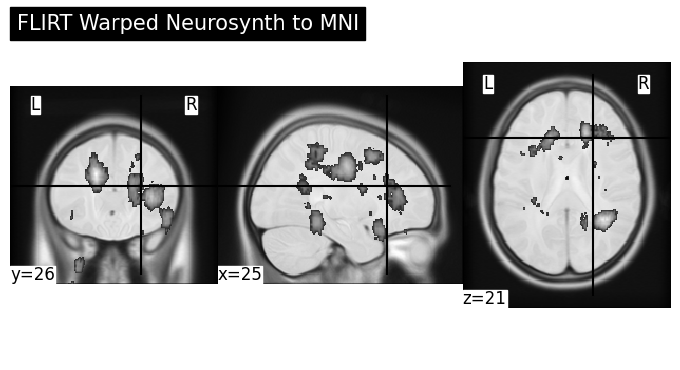

In [12]:
import os
import subprocess
import nibabel as nib
import numpy as np
from nilearn import plotting

# --- IMPORTANT: Ensure your script/notebook is in the project's root directory ---
# --- where the 'ref_activation_ns' folder is located. ---

# 1. Define the path to the MNI template (ENSURE .nii.gz IS INCLUDED)
atlas_mni152_path = "./data/mni_icbm152_asym_A.nii.gz"

# 2. Define the path to the Neurosynth anatomical image (for working memory) (ENSURE .nii.gz IS INCLUDED)
neurosynth_anat_path = "./data/NS_ref_activation_data/working memory_association-test_z_FDR_0.01.nii.gz"

# 3. Define the path to the output transformation matrix
xfm_mat_path = "./data/out/neurosynth/from-neurosynth_to-mniICBM152_asym_C_desc-flirt.mat"

# Define the output warped image path
warped_anat_path = "./data/out/neurosynth/anatomical_space-mni_icbm152_asym_C.nii.gz"

# Check if FSL is installed (flirt is part of FSL)
try:
    subprocess.run(["flirt", "-version"], check=True, capture_output=True)
    fsl_installed = True
except FileNotFoundError:
    fsl_installed = False
    print("Warning: FSL (including flirt) is not found in your system's PATH.")
    print("The original code relies on FSL for registration.")
    print("Please ensure FSL is installed and properly configured to run this code.")

if fsl_installed:
    try:
        # Create the output directory if it doesn't exist
        output_dir = os.path.dirname(xfm_mat_path)
        os.makedirs(output_dir, exist_ok=True)

        # Perform linear registration using flirt via subprocess
        print(f"Running FLIRT registration:")
        flirt_command = [
            "flirt",
            "-in",
            f"{neurosynth_anat_path}",
            "-ref",
            f"{atlas_mni152_path}",
            "-out",
            f"{warped_anat_path}",
            "-omat",
            f"{xfm_mat_path}",
        ]
        process = subprocess.run(flirt_command, check=True, capture_output=True, text=True)
        print("FLIRT registration completed successfully.")
        print("FLIRT output:\n", process.stdout)
        if process.stderr:
            print("FLIRT errors:\n", process.stderr)

        # Optional: Load and display the warped image using nilearn
        try:
            warped_img = nib.load(warped_anat_path)
            background_img = nib.load(atlas_mni152_path)
            plotting.plot_img(
                warped_img,
                title="FLIRT Warped Neurosynth to MNI",
                cmap='gray',  # Try 'gray' or other grayscale colormaps
                threshold=0.1, # Adjust this threshold as needed
                bg_img=background_img, # Overlay on the MNI template
            )
            plotting.show()
        except FileNotFoundError:
            print(f"Warning: Warped image not found at {warped_anat_path} for display.")
        except ImportError:
            print("Warning: nilearn not found. Cannot display warped image.")
        except Exception as e:
            print(f"Error displaying warped image: {e}")

    except FileNotFoundError:
        print("Error: One or more of the input image files were not found. Please check the paths.")
    except subprocess.CalledProcessError as e:
        print(f"Error running FLIRT registration. Return code: {e.returncode}")
        print(f"FLIRT stdout:\n{e.stdout}")
        print(f"FLIRT stderr:\n{e.stderr}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

else:
    print("FSL/FLIRT is required for this code to function as intended.")
    print("Please install FSL and ensure it's in your system's PATH.")
    print("You might need to refer to the FSL installation instructions for your operating system.")